<a href="https://colab.research.google.com/github/Ravi-ranjan1801/Data-Warehousing-Mining-Lab/blob/main/DWM_Lab_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_excel("student_performance.xlsx")
#df.to_csv("student_performance.csv", index=False)

#print("CSV file created successfully!")
df.head()

,Student_ID,Name,Gender,Age,Department,Semester,Attendance,Assignment,Midterm,Endterm,Total,CGPA,Study_Hours,Internet_Usage,Placement
0,1001,Aman Gupta,Male,21,IT,7,68,11,17,43,71,7.54,1,2,No
1,1002,Simran Singh,Male,23,IT,7,88,19,23,50,92,10.00,2,7,Yes
2,1003,Kunal Patel,Female,21,AI,7,66,11,27,28,66,6.99,3,5,No
3,1004,Simran Verma,Female,23,CSE,7,95,14,26,43,83,8.55,1,1,Yes
4,1005,Harsh Gupta,Male,20,IT,7,66,16,23,39,78,8.41,3,3,No


In [5]:
print(df.info())

print("\nShape:", df.shape)

print("\nMissing Values:")

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      250 non-null    int64  
 1   Name            250 non-null    object 
 2   Gender          250 non-null    object 
 3   Age             250 non-null    int64  
 4   Department      250 non-null    object 
 5   Semester        250 non-null    int64  
 6   Attendance      250 non-null    int64  
 7   Assignment      250 non-null    int64  
 8   Midterm         250 non-null    int64  
 9   Endterm         250 non-null    int64  
 10  Total           250 non-null    int64  
 11  CGPA            250 non-null    float64
 12  Study_Hours     250 non-null    int64  
 13  Internet_Usage  250 non-null    int64  
 14  Placement       250 non-null    object 
dtypes: float64(1), int64(10), object(4)
memory usage: 29.4+ KB
None

Shape: (250, 15)

Missing Values:
Student_ID        0
Name  

In [6]:
np.random.seed(42)

# Numeric Columns
numeric_cols = ['Age','Attendance','Assignment','Midterm',
                'Endterm','CGPA','Study_Hours','Internet_Usage']

for col in numeric_cols:
    random_rows = np.random.choice(df.index, size=5, replace=False)
    df.loc[random_rows, col] = np.nan

# Categorical Columns
categorical_cols = ['Gender','Department','Placement']

for col in categorical_cols:
    random_rows = np.random.choice(df.index, size=3, replace=False)
    df.loc[random_rows, col] = np.nan

print(df.isnull().sum())

Student_ID        0
Name              0
Gender            3
Age               5
Department        3
Semester          0
Attendance        5
Assignment        5
Midterm           5
Endterm           5
Total             0
CGPA              5
Study_Hours       5
Internet_Usage    5
Placement         3
dtype: int64


In [7]:
df.to_excel("student_performance_missing.xlsx", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


In [8]:
print(df.isnull().sum())

Student_ID        0
Name              0
Gender            3
Age               5
Department        3
Semester          0
Attendance        5
Assignment        5
Midterm           5
Endterm           5
Total             0
CGPA              5
Study_Hours       5
Internet_Usage    5
Placement         3
dtype: int64


In [9]:
mean_df = df.copy()

numeric_cols = mean_df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    mean_df[col].fillna(mean_df[col].mean(), inplace=True)

print(mean_df.isnull().sum())

Student_ID        0
Name              0
Gender            3
Age               0
Department        3
Semester          0
Attendance        0
Assignment        0
Midterm           0
Endterm           0
Total             0
CGPA              0
Study_Hours       0
Internet_Usage    0
Placement         3
dtype: int64


/tmp/ipykernel_733/1330790843.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mean_df[col].fillna(mean_df[col].mean(), inplace=True)


In [10]:
mean_df.head(10)

,Student_ID,Name,Gender,Age,Department,Semester,Attendance,Assignment,Midterm,Endterm,Total,CGPA,Study_Hours,Internet_Usage,Placement
0,1001,Aman Gupta,Male,21.000000,IT,7,68.0,11.0,17.0,43.0,71,7.54,1.00000,2.0,No
1,1002,Simran Singh,Male,23.000000,IT,7,88.0,19.0,23.0,50.0,92,10.00,2.00000,7.0,Yes
2,1003,Kunal Patel,Female,21.000000,AI,7,66.0,11.0,27.0,28.0,66,6.99,3.00000,5.0,No
3,1004,Simran Verma,Female,23.000000,CSE,7,95.0,14.0,26.0,43.0,83,8.55,1.00000,1.0,Yes
4,1005,Harsh Gupta,Male,20.000000,IT,7,66.0,16.0,23.0,39.0,78,8.41,3.00000,3.0,No
5,1006,Kriti Gupta,Male,20.000000,IT,7,94.0,13.0,20.0,39.0,72,7.60,6.00000,4.0,No
6,1007,Arjun Sharma,Male,21.391837,ECE,7,77.0,11.0,21.0,43.0,75,8.30,3.00000,4.0,Yes
7,1008,Rohit Mishra,Female,21.000000,AI,7,68.0,13.0,23.0,48.0,84,8.97,3.44898,7.0,No
8,1009,Aditya Mishra,Male,20.000000,CSE,7,67.0,12.0,20.0,50.0,82,8.84,5.00000,2.0,No
9,1010,Aditya Gupta,Female,20.000000,CSE,7,94.0,14.0,25.0,28.0,67,7.03,2.00000,8.0,Yes


In [11]:
median_df = df.copy()

numeric_cols = median_df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    median_df[col].fillna(median_df[col].median(), inplace=True)

print(median_df.isnull().sum())

Student_ID        0
Name              0
Gender            3
Age               0
Department        3
Semester          0
Attendance        0
Assignment        0
Midterm           0
Endterm           0
Total             0
CGPA              0
Study_Hours       0
Internet_Usage    0
Placement         3
dtype: int64


/tmp/ipykernel_733/566734947.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  median_df[col].fillna(median_df[col].median(), inplace=True)


In [12]:
median_df.head(10)

,Student_ID,Name,Gender,Age,Department,Semester,Attendance,Assignment,Midterm,Endterm,Total,CGPA,Study_Hours,Internet_Usage,Placement
0,1001,Aman Gupta,Male,21.0,IT,7,68.0,11.0,17.0,43.0,71,7.54,1.0,2.0,No
1,1002,Simran Singh,Male,23.0,IT,7,88.0,19.0,23.0,50.0,92,10.00,2.0,7.0,Yes
2,1003,Kunal Patel,Female,21.0,AI,7,66.0,11.0,27.0,28.0,66,6.99,3.0,5.0,No
3,1004,Simran Verma,Female,23.0,CSE,7,95.0,14.0,26.0,43.0,83,8.55,1.0,1.0,Yes
4,1005,Harsh Gupta,Male,20.0,IT,7,66.0,16.0,23.0,39.0,78,8.41,3.0,3.0,No
5,1006,Kriti Gupta,Male,20.0,IT,7,94.0,13.0,20.0,39.0,72,7.60,6.0,4.0,No
6,1007,Arjun Sharma,Male,21.0,ECE,7,77.0,11.0,21.0,43.0,75,8.30,3.0,4.0,Yes
7,1008,Rohit Mishra,Female,21.0,AI,7,68.0,13.0,23.0,48.0,84,8.97,4.0,7.0,No
8,1009,Aditya Mishra,Male,20.0,CSE,7,67.0,12.0,20.0,50.0,82,8.84,5.0,2.0,No
9,1010,Aditya Gupta,Female,20.0,CSE,7,94.0,14.0,25.0,28.0,67,7.03,2.0,8.0,Yes


In [13]:
mode_df = df.copy()

for col in mode_df.columns:
    mode_df[col].fillna(mode_df[col].mode()[0], inplace=True)

print(mode_df.isnull().sum())

Student_ID        0
Name              0
Gender            0
Age               0
Department        0
Semester          0
Attendance        0
Assignment        0
Midterm           0
Endterm           0
Total             0
CGPA              0
Study_Hours       0
Internet_Usage    0
Placement         0
dtype: int64


/tmp/ipykernel_733/583270816.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mode_df[col].fillna(mode_df[col].mode()[0], inplace=True)
/tmp/ipykernel_733/583270816.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [14]:
mode_df.head(10)

,Student_ID,Name,Gender,Age,Department,Semester,Attendance,Assignment,Midterm,Endterm,Total,CGPA,Study_Hours,Internet_Usage,Placement
0,1001,Aman Gupta,Male,21.0,IT,7,68.0,11.0,17.0,43.0,71,7.54,1.0,2.0,No
1,1002,Simran Singh,Male,23.0,IT,7,88.0,19.0,23.0,50.0,92,10.00,2.0,7.0,Yes
2,1003,Kunal Patel,Female,21.0,AI,7,66.0,11.0,27.0,28.0,66,6.99,3.0,5.0,No
3,1004,Simran Verma,Female,23.0,CSE,7,95.0,14.0,26.0,43.0,83,8.55,1.0,1.0,Yes
4,1005,Harsh Gupta,Male,20.0,IT,7,66.0,16.0,23.0,39.0,78,8.41,3.0,3.0,No
5,1006,Kriti Gupta,Male,20.0,IT,7,94.0,13.0,20.0,39.0,72,7.60,6.0,4.0,No
6,1007,Arjun Sharma,Male,20.0,ECE,7,77.0,11.0,21.0,43.0,75,8.30,3.0,4.0,Yes
7,1008,Rohit Mishra,Female,21.0,AI,7,68.0,13.0,23.0,48.0,84,8.97,2.0,7.0,No
8,1009,Aditya Mishra,Male,20.0,CSE,7,67.0,12.0,20.0,50.0,82,8.84,5.0,2.0,No
9,1010,Aditya Gupta,Female,20.0,CSE,7,94.0,14.0,25.0,28.0,67,7.03,2.0,8.0,Yes


In [15]:
print("Original Missing Values")
print(df.isnull().sum())

print("\nMean Replacement Completed")

print(mean_df.isnull().sum())

print("\nMedian Replacement Completed")

print(median_df.isnull().sum())

print("\nMode Replacement Completed")

print(mode_df.isnull().sum())

Original Missing Values
Student_ID        0
Name              0
Gender            3
Age               5
Department        3
Semester          0
Attendance        5
Assignment        5
Midterm           5
Endterm           5
Total             0
CGPA              5
Study_Hours       5
Internet_Usage    5
Placement         3
dtype: int64

Mean Replacement Completed
Student_ID        0
Name              0
Gender            3
Age               0
Department        3
Semester          0
Attendance        0
Assignment        0
Midterm           0
Endterm           0
Total             0
CGPA              0
Study_Hours       0
Internet_Usage    0
Placement         3
dtype: int64

Median Replacement Completed
Student_ID        0
Name              0
Gender            3
Age               0
Department        3
Semester          0
Attendance        0
Assignment        0
Midterm           0
Endterm           0
Total             0
CGPA              0
Study_Hours       0
Internet_Usage    0
Placement   

In [16]:
normalized_df = mode_df.copy()

numeric_cols = ['Age','Attendance','Assignment','Midterm',
                'Endterm','Total','CGPA',
                'Study_Hours','Internet_Usage']

In [17]:
for col in numeric_cols:
    minimum = normalized_df[col].min()
    maximum = normalized_df[col].max()

    normalized_df[col] = (normalized_df[col]-minimum)/(maximum-minimum)

In [18]:
normalized_df.head()

,Student_ID,Name,Gender,Age,Department,Semester,Attendance,Assignment,Midterm,Endterm,Total,CGPA,Study_Hours,Internet_Usage,Placement
0,1001,Aman Gupta,Male,0.333333,IT,7,0.200,0.1,0.133333,0.72,0.428571,0.380353,0.0,0.142857,No
1,1002,Simran Singh,Male,1.000000,IT,7,0.700,0.9,0.533333,1.00,0.928571,1.000000,0.2,0.857143,Yes
2,1003,Kunal Patel,Female,0.333333,AI,7,0.150,0.1,0.800000,0.12,0.309524,0.241814,0.4,0.571429,No
3,1004,Simran Verma,Female,1.000000,CSE,7,0.875,0.4,0.733333,0.72,0.714286,0.634761,0.0,0.000000,Yes
4,1005,Harsh Gupta,Male,0.000000,IT,7,0.150,0.6,0.533333,0.56,0.595238,0.599496,0.4,0.285714,No


In [19]:
normalized_df[numeric_cols].describe()

,Age,Attendance,Assignment,Midterm,Endterm,Total,CGPA,Study_Hours,Internet_Usage
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,0.454667,0.505000,0.503600,0.548800,0.512640,0.548857,0.519668,0.484000,0.530286
std,0.377807,0.301252,0.325038,0.281151,0.302594,0.208728,0.225981,0.336984,0.317929
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.250000,0.200000,0.333333,0.240000,0.404762,0.350126,0.200000,0.285714
50%,0.333333,0.525000,0.500000,0.566667,0.560000,0.547619,0.539043,0.400000,0.571429
75%,0.666667,0.750000,0.800000,0.800000,0.720000,0.714286,0.682620,0.800000,0.857143
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [20]:
binary_df = mode_df.copy()

In [21]:
for col in numeric_cols:
    avg = binary_df[col].mean()

    binary_df[col] = np.where(binary_df[col] >= avg, 1, 0)

In [22]:
binary_df.head()

,Student_ID,Name,Gender,Age,Department,Semester,Attendance,Assignment,Midterm,Endterm,Total,CGPA,Study_Hours,Internet_Usage,Placement
0,1001,Aman Gupta,Male,0,IT,7,0,0,0,1,0,0,0,0,No
1,1002,Simran Singh,Male,1,IT,7,1,1,0,1,1,1,0,1,Yes
2,1003,Kunal Patel,Female,0,AI,7,0,0,1,0,0,0,0,1,No
3,1004,Simran Verma,Female,1,CSE,7,1,0,1,1,1,1,0,0,Yes
4,1005,Harsh Gupta,Male,0,IT,7,0,1,0,1,1,1,0,0,No


In [23]:
for col in numeric_cols:
    print(col)
    print(binary_df[col].value_counts())
    print()

Age
Age
0    140
1    110
Name: count, dtype: int64

Attendance
Attendance
1    126
0    124
Name: count, dtype: int64

Assignment
Assignment
0    136
1    114
Name: count, dtype: int64

Midterm
Midterm
0    125
1    125
Name: count, dtype: int64

Endterm
Endterm
1    136
0    114
Name: count, dtype: int64

Total
Total
0    132
1    118
Name: count, dtype: int64

CGPA
CGPA
1    133
0    117
Name: count, dtype: int64

Study_Hours
Study_Hours
0    127
1    123
Name: count, dtype: int64

Internet_Usage
Internet_Usage
1    143
0    107
Name: count, dtype: int64



In [24]:
print("Original Dataset")

display(df.head())

print("Mean Imputation")

display(mean_df.head())

print("Median Imputation")

display(median_df.head())

print("Mode Imputation")

display(mode_df.head())

print("Max-Min Normalization")

display(normalized_df.head())

print("0/1 Normalization")

display(binary_df.head())

Original Dataset


,Student_ID,Name,Gender,Age,Department,Semester,Attendance,Assignment,Midterm,Endterm,Total,CGPA,Study_Hours,Internet_Usage,Placement
0,1001,Aman Gupta,Male,21.0,IT,7,68.0,11.0,17.0,43.0,71,7.54,1.0,2.0,No
1,1002,Simran Singh,Male,23.0,IT,7,88.0,19.0,23.0,50.0,92,10.00,2.0,7.0,Yes
2,1003,Kunal Patel,Female,21.0,AI,7,66.0,11.0,27.0,28.0,66,6.99,3.0,5.0,No
3,1004,Simran Verma,Female,23.0,CSE,7,95.0,14.0,26.0,43.0,83,8.55,1.0,1.0,Yes
4,1005,Harsh Gupta,Male,20.0,IT,7,66.0,16.0,23.0,39.0,78,8.41,3.0,3.0,No


Mean Imputation


,Student_ID,Name,Gender,Age,Department,Semester,Attendance,Assignment,Midterm,Endterm,Total,CGPA,Study_Hours,Internet_Usage,Placement
0,1001,Aman Gupta,Male,21.0,IT,7,68.0,11.0,17.0,43.0,71,7.54,1.0,2.0,No
1,1002,Simran Singh,Male,23.0,IT,7,88.0,19.0,23.0,50.0,92,10.00,2.0,7.0,Yes
2,1003,Kunal Patel,Female,21.0,AI,7,66.0,11.0,27.0,28.0,66,6.99,3.0,5.0,No
3,1004,Simran Verma,Female,23.0,CSE,7,95.0,14.0,26.0,43.0,83,8.55,1.0,1.0,Yes
4,1005,Harsh Gupta,Male,20.0,IT,7,66.0,16.0,23.0,39.0,78,8.41,3.0,3.0,No


Median Imputation


...

,Student_ID,Name,Gender,Age,Department,Semester,Attendance,Assignment,Midterm,Endterm,Total,CGPA,Study_Hours,Internet_Usage,Placement
0,1001,Aman Gupta,Male,21.0,IT,7,68.0,11.0,17.0,43.0,71,7.54,1.0,2.0,No
1,1002,Simran Singh,Male,23.0,IT,7,88.0,19.0,23.0,50.0,92,10.00,2.0,7.0,Yes
2,1003,Kunal Patel,Female,21.0,AI,7,66.0,11.0,27.0,28.0,66,6.99,3.0,5.0,No
3,1004,Simran Verma,Female,23.0,CSE,7,95.0,14.0,26.0,43.0,83,8.55,1.0,1.0,Yes
4,1005,Harsh Gupta,Male,20.0,IT,7,66.0,16.0,23.0,39.0,78,8.41,3.0,3.0,No


Max-Min Normalization


,Student_ID,Name,Gender,Age,Department,Semester,Attendance,Assignment,Midterm,Endterm,Total,CGPA,Study_Hours,Internet_Usage,Placement
0,1001,Aman Gupta,Male,0.333333,IT,7,0.200,0.1,0.133333,0.72,0.428571,0.380353,0.0,0.142857,No
1,1002,Simran Singh,Male,1.000000,IT,7,0.700,0.9,0.533333,1.00,0.928571,1.000000,0.2,0.857143,Yes
2,1003,Kunal Patel,Female,0.333333,AI,7,0.150,0.1,0.800000,0.12,0.309524,0.241814,0.4,0.571429,No
3,1004,Simran Verma,Female,1.000000,CSE,7,0.875,0.4,0.733333,0.72,0.714286,0.634761,0.0,0.000000,Yes
4,1005,Harsh Gupta,Male,0.000000,IT,7,0.150,0.6,0.533333,0.56,0.595238,0.599496,0.4,0.285714,No


0/1 Normalization


,Student_ID,Name,Gender,Age,Department,Semester,Attendance,Assignment,Midterm,Endterm,Total,CGPA,Study_Hours,Internet_Usage,Placement
0,1001,Aman Gupta,Male,0,IT,7,0,0,0,1,0,0,0,0,No
1,1002,Simran Singh,Male,1,IT,7,1,1,0,1,1,1,0,1,Yes
2,1003,Kunal Patel,Female,0,AI,7,0,0,1,0,0,0,0,1,No
3,1004,Simran Verma,Female,1,CSE,7,1,0,1,1,1,1,0,0,Yes
4,1005,Harsh Gupta,Male,0,IT,7,0,1,0,1,1,1,0,0,No


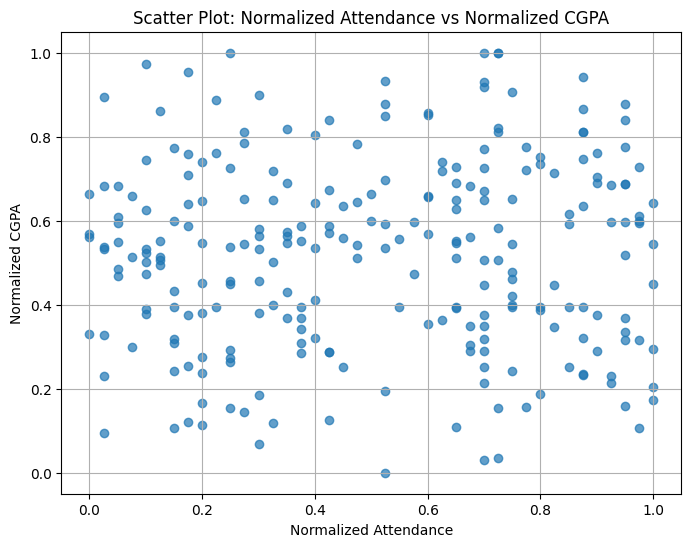

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(normalized_df['Attendance'],
            normalized_df['CGPA'],
            alpha=0.7)

plt.title("Scatter Plot: Normalized Attendance vs Normalized CGPA")
plt.xlabel("Normalized Attendance")
plt.ylabel("Normalized CGPA")

plt.grid(True)

plt.show()